In [2]:
import json
import numpy as np
import matplotlib.pyplot as plt
from scipy.constants import golden
from collections import defaultdict
import os
import numpy as np 

# Keep your existing constants
ONE_COL_WIDTH_INCH = 2.75
TWO_COL_WIDTH_INCH = 5.5
ONE_COL_GOLDEN_RATIO_HEIGHT_INCH = ONE_COL_WIDTH_INCH / golden
TWO_COL_GOLDEN_RATIO_HEIGHT_INCH = TWO_COL_WIDTH_INCH / golden

plt.style.use("lamalab.mplstyle")


Bad key font.dir in file lamalab.mplstyle, line 56 ('font.dir: /home/so87pot/n0w0f/attention_analysis/fonts')
You probably need to get an updated matplotlibrc file from
https://github.com/matplotlib/matplotlib/blob/v3.9.2/lib/matplotlib/mpl-data/matplotlibrc
or from the matplotlib source distribution


In [3]:
def range_frame(ax, x, y, pad=0.1):
    y_min, y_max = np.array(y).min(), np.array(y).max()
    filtered_x = [val for val in x if val is not None]
    if filtered_x:  
        x_min, x_max = np.min(filtered_x), np.max(filtered_x)  
    else:  
        x_min, x_max = 0, 1  # Default values or handle accordingly

    ax.set_ylim(y_min - pad * (y_max - y_min), y_max + pad * (y_max - y_min))
    ax.set_xlim(x_min - pad * (x_max - x_min), x_max + pad * (x_max - x_min))
    ax.spines["left"].set_position(("outward", 10))
    ax.spines["bottom"].set_position(("outward", 10))
    ax.spines["left"].set_bounds(y_min, y_max)
    ax.spines["bottom"].set_bounds(x_min, x_max)
    ax.spines["right"].set_visible(False)
    ax.spines["top"].set_visible(False)



Bad key font.dir in file lamalab.mplstyle, line 56 ('font.dir: /home/so87pot/n0w0f/attention_analysis/fonts')
You probably need to get an updated matplotlibrc file from
https://github.com/matplotlib/matplotlib/blob/v3.9.2/lib/matplotlib/mpl-data/matplotlibrc
or from the matplotlib source distribution


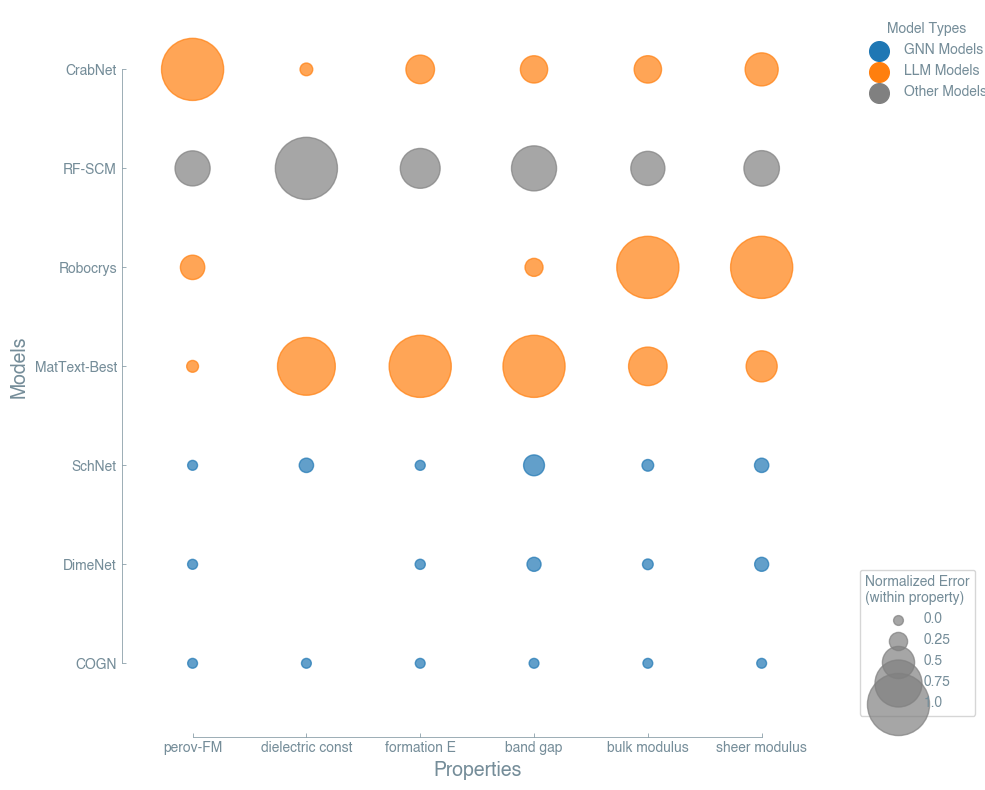

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np



plt.style.use("lamalab.mplstyle")

# Define the data
data = {
    'COGN': [0.0269, 0.3088, 0.017, 0.1559, 0.0535, 0.0689],
    #'CGCNN': [0.0452, 0.5988, 0.0337, 0.2972, 0.0712, 0.0895],
    'DimeNet': [0.0376, None, 0.0235, 0.1993, 0.0572, 0.0792],
    'SchNet': [0.0342, 0.3277, 0.0218, 0.2352, 0.059, 0.0796],
    'MatText-Best': [0.067748, 0.41169, 0.175, 0.42, 0.086, 0.09922],
    #'LLM-prop': [None, None, None, 0.241, None, None],
    'Robocrys': [0.165, None, None, 0.221, 0.107, 0.132],
    'RF-SCM': [0.2355, 0.4196, 0.1165, 0.3452, 0.082, 0.104],
    'CrabNet': [0.4065, 0.3234, 0.0862, 0.2655, 0.0758, 0.1014],
    'Dummy': [0.5660,0.8088, 1.0059,1.3272,0.2897,0.2931]

}

# Create a DataFrame
index = ['perov-FM', 'dielectric const', 'formation E', 'band gap', 'bulk modulus', 'sheer modulus']
df = pd.DataFrame(data, index=index)

# Normalize the data by row (each property separately)
normalized_df = df.apply(lambda x: (x - x.min()) / (x.max() - x.min()), axis=1)

# Define model categories
gnn_models = ['COGN', 'CGCNN', 'DimeNet', 'SchNet']
llm_models = ['MatText-Best', 'LLM-prop', 'Robocrys','CrabNet']
other_models = ['Dummy']

# Create color mapping
def get_model_color(model):
    if model in gnn_models:
        return '#1f77b4'  # Blue for GNN models
    elif model in llm_models:
        return '#ff7f0e'  # Orange for LLM models
    else:
        return '#808080'  # Gray for other models

# Create meshgrid for bubble positions
models = df.columns.tolist()
properties = df.index.tolist()
x = np.arange(len(properties))
y = np.arange(len(models))
X, Y = np.meshgrid(x, y)

# Flatten the arrays for plotting
x_flat = X.flatten()
y_flat = Y.flatten()

# Get normalized values and handle NaN
values = normalized_df.T.values.flatten()
mask = ~np.isnan(values)

# Filter out NaN values
x_filtered = x_flat[mask]
y_filtered = y_flat[mask]
values_filtered = values[mask]

# Scale the bubble sizes with power scaling to emphasize differences
# Use power scaling to make differences more apparent
power_scale = 2  # Increase this to make size differences more dramatic
min_size = 50  # Minimum bubble size
max_size = 2000  # Increased maximum for better contrast
size_scale = max_size - min_size
sizes = min_size + (values_filtered ** power_scale) * size_scale

# Create colors for each point
colors = []
for y_idx in y_filtered:
    model = models[y_idx]
    colors.append(get_model_color(model))

# Create the figure with standard size
fig, ax = plt.subplots(figsize=(10, 8))

# Create the bubble plot
scatter = ax.scatter(x_filtered, y_filtered, s=sizes, alpha=0.7,
                     c=colors,
                       #edgecolors='black', linewidth=0.8
                       )

# Customize the plot
ax.set_xticks(x)
ax.set_xticklabels(properties, rotation=45, ha='right', fontsize=12)
ax.set_yticks(y)
ax.set_yticklabels(models, fontsize=12)
ax.set_xlabel('Properties', fontsize=14)
ax.set_ylabel('Models', fontsize=14)

# Apply range frame with proper padding
range_frame(ax, x, y, pad=0.1)

# Create custom legend for model types
legend_elements = [
    plt.scatter([], [], c='#1f77b4', s=200,  label='GNN Models'),
    plt.scatter([], [], c='#ff7f0e', s=200,  label='LLM Models'),
    plt.scatter([], [], c='#808080', s=200,  label='Other Models')
]

type_legend = ax.legend(handles=legend_elements, loc='upper left', bbox_to_anchor=(1.05, 1), title='Model Types')
ax.add_artist(type_legend)

# Create dummy scatter plots for legend
legend_sizes = [min_size, min_size + (0.25**power_scale)*size_scale,
                min_size + (0.5**power_scale)*size_scale,
                min_size + (0.75**power_scale)*size_scale,
                max_size]
legend_labels = ['0.0', '0.25', '0.5', '0.75', '1.0']

size_legend_elements = []
for size, label in zip(legend_sizes, legend_labels):
    size_legend_elements.append(plt.scatter([], [], s=size, c='gray', alpha=0.7,
                                          #edgecolors='black', linewidth=0.8
                                          ))

size_legend = ax.legend(size_legend_elements, legend_labels, scatterpoints=1,
                        loc='lower left', bbox_to_anchor=(1.05, 0),
                        title='Normalized Error\n(within property)', frameon=True)

# Adjust layout to prevent overlap
plt.tight_layout()

# Show the plot
plt.show()

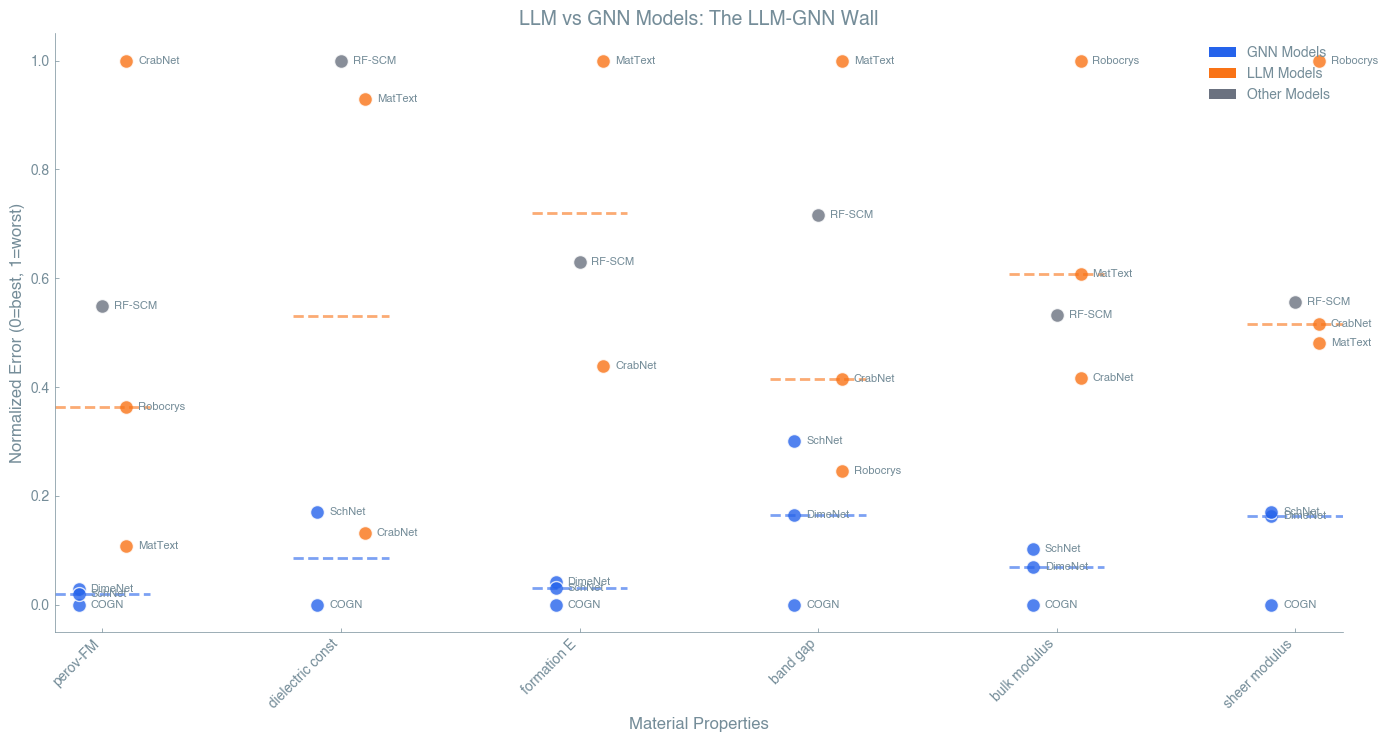

In [17]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.patches import Patch

# Define the data
raw_data = {
    'COGN': [0.0269, 0.3088, 0.017, 0.1559, 0.0535, 0.0689],
    'DimeNet': [0.0376, None, 0.0235, 0.1993, 0.0572, 0.0792],
    'SchNet': [0.0342, 0.3277, 0.0218, 0.2352, 0.059, 0.0796],
    'MatText-Best': [0.067748, 0.41169, 0.175, 0.42, 0.086, 0.09922],
    'Robocrys': [0.165, None, None, 0.221, 0.107, 0.132],
    'RF-SCM': [0.2355, 0.4196, 0.1165, 0.3452, 0.082, 0.104],
    'CrabNet': [0.4065, 0.3234, 0.0862, 0.2655, 0.0758, 0.1014]
}

properties = ['perov-FM', 'dielectric const', 'formation E', 'band gap', 'bulk modulus', 'sheer modulus']

# Define model types
model_types = {
    'COGN': 'GNN',
    'DimeNet': 'GNN',
    'SchNet': 'GNN',
    'MatText-Best': 'LLM',
    'Robocrys': 'LLM',
    'RF-SCM': 'Other',
    'CrabNet': 'LLM'
}

# Convert to DataFrame for easier manipulation
df = pd.DataFrame(raw_data, index=properties).T
df['model_type'] = df.index.map(model_types)

# Initialize lists to store normalized data points
models = []
prop_indices = []
errors = []
normalized_errors = []
model_type_labels = []
orig_errors = []

# Process each property to normalize errors
for prop_idx, prop in enumerate(properties):
    prop_data = df[prop].dropna()
    if len(prop_data) > 0:
        min_val = prop_data.min()
        max_val = prop_data.max()
        range_val = max_val - min_val
        
        for model in prop_data.index:
            value = prop_data[model]
            normalized_value = 0 if range_val == 0 else (value - min_val) / range_val
            
            models.append(model)
            prop_indices.append(prop_idx)
            errors.append(normalized_value)
            normalized_errors.append(normalized_value)
            model_type_labels.append(df.loc[model, 'model_type'])
            orig_errors.append(value)

# Create a figure with adequate size
plt.figure(figsize=(14, 8))

# Define jitter amount
jitter_amount = 0.1
jitters = []

# Add slight horizontal jitter to avoid overlapping points
for i, model_type in enumerate(model_type_labels):
    if model_type == 'GNN':
        jitter = -jitter_amount
    elif model_type == 'LLM':
        jitter = jitter_amount
    else:
        jitter = 0
    jitters.append(jitter)

# Define colors for model types
colors = {'GNN': '#2563eb', 'LLM': '#f97316', 'Other': '#6b7280'}
color_points = [colors[t] for t in model_type_labels]

# Scatter plot with model labels
for i in range(len(models)):
    x_pos = prop_indices[i] + jitters[i]
    plt.scatter(x_pos, errors[i], color=color_points[i], s=100, alpha=0.8, 
                edgecolors='white', linewidth=1)
    
    # Add model name as text label next to the point
    plt.annotate(models[i].replace('-Best', ''), 
                 (x_pos + 0.05, errors[i]),
                 fontsize=8,
                 va='center')

# Calculate and plot median lines for model types per property
for prop_idx in range(len(properties)):
    for model_type in ['GNN', 'LLM']:
        type_indices = [i for i, t in enumerate(model_type_labels) 
                      if t == model_type and prop_indices[i] == prop_idx]
        
        if type_indices:
            type_errors = [errors[i] for i in type_indices]
            median_error = np.median(type_errors)
            
            plt.plot([prop_idx - 0.2, prop_idx + 0.2], 
                     [median_error, median_error], 
                     color=colors[model_type], 
                     linestyle='--', 
                     alpha=0.6,
                     linewidth=2)

# Set the axis labels, limits and title
plt.xlabel('Material Properties', fontsize=12)
plt.ylabel('Normalized Error (0=best, 1=worst)', fontsize=12)
plt.title('LLM vs GNN Models: The LLM-GNN Wall', fontsize=14, fontweight='bold')

# Set the x-ticks to property names
plt.xticks(range(len(properties)), properties, rotation=45, ha='right')

# Set y-axis limits
plt.ylim(-0.05, 1.05)

# Add a grid
plt.grid(False)

# Create custom legend
legend_elements = [
    Patch(facecolor=colors['GNN'], label='GNN Models'),
    Patch(facecolor=colors['LLM'], label='LLM Models'),
    Patch(facecolor=colors['Other'], label='Other Models')
]
plt.legend(handles=legend_elements, loc='upper right')

# Adjust layout
plt.tight_layout(rect=[0, 0.03, 1, 0.97])

# Add tooltips with original error values using annotation
annot = plt.annotate("", xy=(0,0), xytext=(20,20), textcoords="offset points",
                     bbox=dict(boxstyle="round", fc="w"),
                     arrowprops=dict(arrowstyle="->"))
annot.set_visible(False)

# Save the figure
plt.savefig('llm_gnn_wall.png', dpi=300, bbox_inches='tight')

# Show the plot
plt.show()




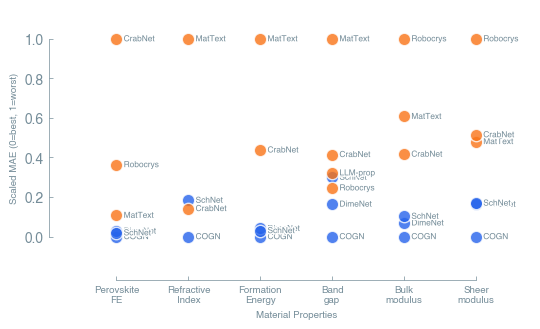

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.patches import Patch
import matplotlib.patheffects as path_effects

# Define range_frame function
def range_frame(ax, x, y, pad=0.1):
    y_min, y_max = np.array(y).min(), np.array(y).max()
    filtered_x = [val for val in x if val is not None]
    if filtered_x:  
        x_min, x_max = np.min(filtered_x), np.max(filtered_x)  
    else:  
        x_min, x_max = 0, 1  # Default values or handle accordingly

    ax.set_ylim(y_min - pad * (y_max - y_min), y_max + pad * (y_max - y_min))
    ax.set_xlim(x_min - pad * (x_max - x_min), x_max + pad * (x_max - x_min))
    ax.spines["left"].set_position(("outward", 10))
    ax.spines["bottom"].set_position(("outward", 10))
    ax.spines["left"].set_bounds(y_min, y_max)
    ax.spines["bottom"].set_bounds(x_min, x_max)
    ax.spines["right"].set_visible(False)
    ax.spines["top"].set_visible(False)

# Define the data
data = {
    'COGN': [0.0269, 0.3088, 0.017, 0.1559, 0.0535, 0.0689],
    #'CGCNN': [0.0452, 0.5988, 0.0337, 0.2972, 0.0712, 0.0895],
    'DimeNet': [0.0376, None, 0.0235, 0.1993, 0.0572, 0.0792],
    'SchNet': [0.0342, 0.3277, 0.0218, 0.2352, 0.059, 0.0796],
    'MatText-Best': [0.067748, 0.41169, 0.175, 0.42, 0.086, 0.09922],
    'LLM-prop': [None, None, None, 0.241, None, None],
    'Robocrys': [0.165, None, None, 0.221, 0.107, 0.132],
    'RF-SCM': [0.2355, 0.4196, 0.1165, 0.3452, 0.082, 0.104],
    'CrabNet': [0.4065, 0.3234, 0.0862, 0.2655, 0.0758, 0.1014],
    'Dummy': [0.5660,0.8088, 1.0059,1.3272,0.2897,0.2931]

}

properties = ['Perovskite\nFE', 'Refractive\nIndex', 'Formation\nEnergy', 'Band\ngap', 'Bulk\nmodulus', 'Sheer\nmodulus']

# Define model types
model_types = {
    'COGN': 'GNN',
    'DimeNet': 'GNN',
    'SchNet': 'GNN',
    'MatText-Best': 'LLM',
    'Robocrys': 'LLM',
    'RF-SCM': 'Other',
    'CrabNet': 'LLM',
    'LLM-prop': 'LLM',
    'Dummy': 'Other'
}

# Convert to DataFrame for easier manipulation
df = pd.DataFrame(raw_data, index=properties).T
df['model_type'] = df.index.map(model_types)

# Function to normalize data per property
def normalize_property(series):
    """Normalize a property series so that min value is 0 and max value is 1"""
    valid = series.dropna()
    if len(valid) <= 1:
        return series  # Can't normalize single value
    min_val = valid.min()
    max_val = valid.max()
    range_val = max_val - min_val
    if range_val == 0:
        return series  # Can't normalize if all values are the same
    return (series - min_val) / range_val

# Create a new DataFrame for normalized values
normalized_df = pd.DataFrame(index=df.index)
normalized_df['model_type'] = df['model_type']

# Normalize each property
for prop in properties:
    normalized_df[prop] = normalize_property(df[prop])

# Create a figure with adequate size
fig, ax = plt.subplots(figsize=(TWO_COL_WIDTH_INCH, TWO_COL_GOLDEN_RATIO_HEIGHT_INCH))  # Replace with your desired dimensions

# Create dictionaries to store GNN min and LLM min for each property
gnn_mins = {}
llm_mins = {}

# Collect all y values for range_frame
all_y_values = []

# Plot each model type with different colors
for model_type, color in [('GNN', '#2563eb'), ('LLM', '#f97316'), ('Other', '#6b7280')]:
    # Get models of this type
    type_models = normalized_df[normalized_df['model_type'] == model_type].index
    
    for model in type_models:
        model_data = normalized_df.loc[model, properties].copy()
        model_orig_data = df.loc[model, properties].copy()
        
        # Plot each data point for this model
        for i, prop in enumerate(properties):
            if pd.notna(model_data[prop]):
                x_pos = i
                y_pos = model_data[prop]
                all_y_values.append(y_pos)  # Collect y values for range_frame
                
                # Store minimum values for GNN and LLM models
                if model_type == 'GNN' and (prop not in gnn_mins or y_pos < gnn_mins[prop][1]):
                    gnn_mins[prop] = (x_pos, y_pos, model)
                elif model_type == 'LLM' and (prop not in llm_mins or y_pos < llm_mins[prop][1]):
                    llm_mins[prop] = (x_pos, y_pos, model)
                
                # Plot the point
                ax.scatter(x_pos, y_pos, color=color, s=80, alpha=0.8, 
                           edgecolors='white', linewidth=1, zorder=3)
                
                # Add model name label with outline for contrast
                text = ax.text(x_pos + 0.1, y_pos, model.replace('-Best', ''),
                               fontsize=6, va='center', ha='left', zorder=4)
                text.set_path_effects([path_effects.withStroke(linewidth=2, foreground='white')])


# Apply range frame to the plot
x_values = list(range(len(properties)))
range_frame(ax, x_values, all_y_values, pad=0.15)
   
# Set the axis labels
ax.set_xlabel('Material Properties', fontsize=7, fontweight='bold')
ax.set_ylabel('Scaled MAE (0=best, 1=lowest)', fontsize=7, fontweight='bold')

# Set the x-ticks to property names
ax.set_xticks(range(len(properties)))
ax.set_xticklabels([p.replace(' ', '\n') for p in properties], fontsize=7)

# Add a grid
ax.grid(False)#, linestyle='--', alpha=0.3, zorder=0)

# Create custom legend
# legend_elements = [
#     Patch(facecolor='#2563eb', label='GNN Models'),
#     Patch(facecolor='#f97316', label='LLM Models'),
#     Patch(facecolor='#6b7280', label='Other Models'),
#     Patch(facecolor='#9333ea', alpha=0.2, label='LLM-GNN Wall')
# ]
# ax.legend(handles=legend_elements, loc='upper right', fontsize=7)

# Adjust layout and save
plt.tight_layout()
plt.savefig('llm_gnn_wall.png', dpi=300, bbox_inches='tight')
plt.show()

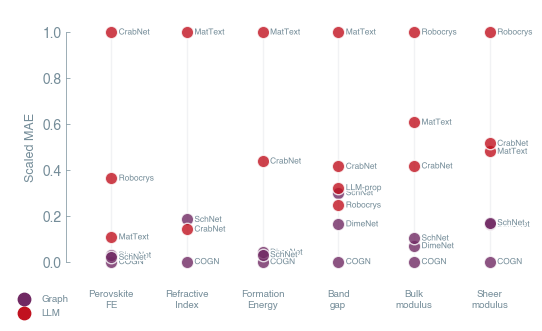

In [135]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.patches import Patch
import matplotlib.patheffects as path_effects

# Define range_frame function
def range_frame(ax, x, y, pad=0.1):
    y_min, y_max = np.array(y).min(), np.array(y).max()
    filtered_x = [val for val in x if val is not None]
    if filtered_x:  
        x_min, x_max = np.min(filtered_x), np.max(filtered_x)  
    else:  
        x_min, x_max = 0, 1  # Default values or handle accordingly

    ax.set_ylim(y_min - pad * (y_max - y_min), y_max + pad * (y_max - y_min))
    ax.set_xlim(x_min - pad * (x_max - x_min), x_max + pad * (x_max - x_min))
    ax.spines["left"].set_position(("outward", 5))  # Reduced from 10 to 5
    ax.spines["bottom"].set_visible(False)  # Hide bottom spine since we're using vertical lines
    ax.spines["left"].set_bounds(y_min, y_max)
    ax.spines["right"].set_visible(False)
    ax.spines["top"].set_visible(False)

# Define the data
data = {
    'COGN': [0.0269, 0.3088, 0.017, 0.1559, 0.0535, 0.0689],
    #'CGCNN': [0.0452, 0.5988, 0.0337, 0.2972, 0.0712, 0.0895],
    'DimeNet': [0.0376, None, 0.0235, 0.1993, 0.0572, 0.0792],
    'SchNet': [0.0342, 0.3277, 0.0218, 0.2352, 0.059, 0.0796],
    'MatText-Best': [0.067748, 0.41169, 0.175, 0.42, 0.086, 0.09922],
    'LLM-prop': [None, None, None, 0.241, None, None],
    'Robocrys': [0.165, None, None, 0.221, 0.107, 0.132],
   # 'RF-SCM': [0.2355, 0.4196, 0.1165, 0.3452, 0.082, 0.104],
    'CrabNet': [0.4065, 0.3234, 0.0862, 0.2655, 0.0758, 0.1014],
    #'Dummy': [0.5660, 0.8088, 1.0059, 1.3272, 0.2897, 0.2931]
}

properties = ['Perovskite\nFE', 'Refractive\nIndex', 'Formation\nEnergy', 'Band\ngap', 'Bulk\nmodulus', 'Sheer\nmodulus']

# Define model types
model_types = {
    'COGN': 'GNN',
    'DimeNet': 'GNN',
    'SchNet': 'GNN',
    'MatText-Best': 'LLM',
    'Robocrys': 'LLM',
    'RF-SCM': 'Other',
    'CrabNet': 'LLM',
    'LLM-prop': 'LLM',
    'Dummy': 'Other'
}

# Convert to DataFrame for easier manipulation
df = pd.DataFrame(data, index=properties).T
df['model_type'] = df.index.map(model_types)

# Function to normalize data per property
def normalize_property(series):
    """Normalize a property series so that min value is 0 and max value is 1"""
    valid = series.dropna()
    if len(valid) <= 1:
        return series  # Can't normalize single value
    min_val = valid.min()
    max_val = valid.max()
    range_val = max_val - min_val
    if range_val == 0:
        return series  # Can't normalize if all values are the same
    return (series - min_val) / range_val

# Create a new DataFrame for normalized values
normalized_df = pd.DataFrame(index=df.index)
normalized_df['model_type'] = df['model_type']

# Create a new DataFrame for normalized values (for visualization)
normalized_size_df = pd.DataFrame(index=df.index)
normalized_size_df['model_type'] = df['model_type']

# Normalize each property
for prop in properties:
    normalized_df[prop] = normalize_property(df[prop])
    # For point sizes, normalize directly from original error values (1 = worst, 0 = best)
    normalized_size_df[prop] = normalize_property(df[prop])


fig, ax = plt.subplots(figsize=(TWO_COL_WIDTH_INCH, TWO_COL_GOLDEN_RATIO_HEIGHT_INCH))

# Create dictionaries to store GNN min and LLM min for each property
gnn_mins = {}
llm_mins = {}

# Collect all y values for range_frame
all_y_values = []

# Draw vertical lines for each property

# Function to scale point size based on normalized error (1 = biggest point)
def scale_point_size(normalized_value, min_size=40, max_size=250):
    """Scale point size based on normalized value - 1 (worst) = largest point"""
    return min_size + normalized_value * (max_size - min_size)

# Plot each model type with different colors
for model_type, color in [('GNN', '#702963'), ('LLM', '#c1121f'), ('Other', '#6b7280')]:
    # Get models of this type
    type_models = normalized_df[normalized_df['model_type'] == model_type].index
    
    for model in type_models:
        model_data = normalized_df.loc[model, properties].copy()
        size_data = normalized_size_df.loc[model, properties].copy()  # For point sizing
        
        # Plot each data point for this model
        for i, prop in enumerate(properties):
            if pd.notna(model_data[prop]):
                x_pos = i
                y_pos = model_data[prop]
                all_y_values.append(y_pos)  # Collect y values for range_frame
                
                # Store minimum values for GNN and LLM models
                if model_type == 'GNN' and (prop not in gnn_mins or y_pos < gnn_mins[prop][1]):
                    gnn_mins[prop] = (x_pos, y_pos, model)
                elif model_type == 'LLM' and (prop not in llm_mins or y_pos < llm_mins[prop][1]):
                    llm_mins[prop] = (x_pos, y_pos, model)
                
                # Calculate point size based on normalized error (bigger error = bigger point)
                norm_error = size_data[prop]
                # point_size = scale_point_size(norm_error)
                
                # Plot the point
                ax.scatter(x_pos, y_pos, color=color, s=80, alpha=0.8, 
                           edgecolors='white', linewidth=1, zorder=3)
                
                # Add model name label with outline for contrast
                text = ax.text(x_pos + 0.1, y_pos, model.replace('-Best', ''),
                               fontsize=6, va='center', ha='left', zorder=4)
                text.set_path_effects([path_effects.withStroke(linewidth=2, foreground='white')])

# Apply range frame to the plot
x_values = list(range(len(properties)))
range_frame(ax, x_values, all_y_values, pad=0.1)  # Reduced padding for tighter fit
   
# Set the axis labels
#ax.set_xlabel('Material Properties', fontsize=7, fontweight='bold')
ax.set_ylabel('Scaled MAE', fontsize=9, fontweight='bold')

# Set the x-ticks to property names
ax.set_xticks(range(len(properties)))
ax.set_xticklabels(properties, fontsize=7)
ax.tick_params(axis='x', which='both', bottom=False)  # Remove x-axis ticks

for i in range(len(properties)):
    # Get y-axis limits
    y_min, y_max = ax.get_ylim()
    ax.axvline(x=i, color='#d1d5db', alpha=0.3, linestyle='-', ymin=0.1, ymax=0.9, zorder=0)


# Create a custom legend for model types
legend_elements = [
    plt.scatter([], [], c='#702963', s=80, label='Graph'),
    plt.scatter([], [], c='#c1121f', s=80, label='LLM'),
]
ax.legend(handles=legend_elements, loc='lower left', 
          bbox_to_anchor=(-0.15, -0.15),
          fontsize=7)



# Adjust layout and save
plt.tight_layout()
output_dir = "fig3"
os.makedirs(output_dir, exist_ok=True)
plot_filename = os.path.join(output_dir, "llm_gnn_wall_1.pdf")
plt.savefig(plot_filename,format='pdf', bbox_inches='tight')
plt.show()

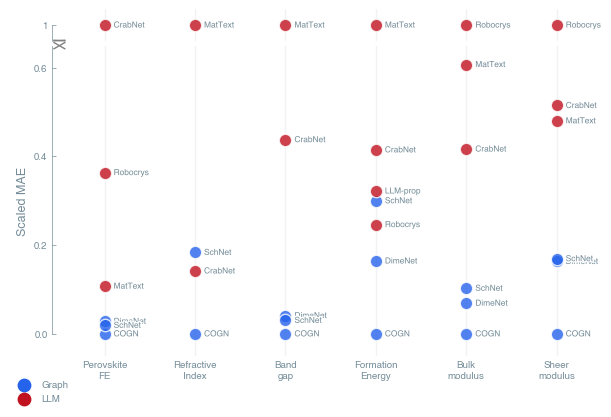

In [124]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.patches import Patch
import matplotlib.patheffects as path_effects
import os
from matplotlib import gridspec
from matplotlib.ticker import MultipleLocator

# Constants for figure size
TWO_COL_WIDTH_INCH = 7.0  # Adjust as needed
TWO_COL_GOLDEN_RATIO_HEIGHT_INCH = 4.5  # Adjust as needed

# Define the data
data = {
    'COGN': [0.0269, 0.3088, 0.017, 0.1559, 0.0535, 0.0689],
    #'CGCNN': [0.0452, 0.5988, 0.0337, 0.2972, 0.0712, 0.0895],
    'DimeNet': [0.0376, None, 0.0235, 0.1993, 0.0572, 0.0792],
    'SchNet': [0.0342, 0.3277, 0.0218, 0.2352, 0.059, 0.0796],
    'MatText-Best': [0.067748, 0.41169, 0.175, 0.42, 0.086, 0.09922],
    'LLM-prop': [None, None, None, 0.241, None, None],
    'Robocrys': [0.165, None, None, 0.221, 0.107, 0.132],
   # 'RF-SCM': [0.2355, 0.4196, 0.1165, 0.3452, 0.082, 0.104],
    'CrabNet': [0.4065, 0.3234, 0.0862, 0.2655, 0.0758, 0.1014],
    #'Dummy': [0.5660, 0.8088, 1.0059, 1.3272, 0.2897, 0.2931]
}

# This is the order you want to plot the properties in
# The issue in the previous code was that you weren't using this order when plotting
property_indices = {
    'Perovskite\nFE': 0,
    'Refractive\nIndex': 1, 
    'Band\ngap': 2,  
    'Formation\nEnergy': 3, 
    'Bulk\nmodulus': 4, 
    'Sheer\nmodulus': 5
}

# Maintain the ordered list of properties
properties = ['Perovskite\nFE', 'Refractive\nIndex', 'Band\ngap', 'Formation\nEnergy',  'Bulk\nmodulus',   'Sheer\nmodulus']

# Define model types
model_types = {
    'COGN': 'GNN',
    'DimeNet': 'GNN',
    'SchNet': 'GNN',
    'MatText-Best': 'LLM',
    'Robocrys': 'LLM',
    'RF-SCM': 'Other',
    'CrabNet': 'LLM',
    'LLM-prop': 'LLM',
    'Dummy': 'Other'
}

# Function to normalize data per property
def normalize_property(series):
    """Normalize a property series so that min value is 0 and max value is 1"""
    valid = series.dropna()
    if len(valid) <= 1:
        return series  # Can't normalize single value
    min_val = valid.min()
    max_val = valid.max()
    range_val = max_val - min_val
    if range_val == 0:
        return series  # Can't normalize if all values are the same
    return (series - min_val) / range_val

# Create a dictionary to store normalized values for each model and property
normalized_data = {}
normalized_size_data = {}

# First, organize data by model and property
for model, values in data.items():
    normalized_data[model] = {}
    normalized_size_data[model] = {}
    model_type = model_types.get(model, 'Other')
    normalized_data[model]['model_type'] = model_type
    normalized_size_data[model]['model_type'] = model_type

# Organize data by property to normalize correctly
property_data = {}
for i, prop in enumerate(properties):
    property_data[prop] = {}
    for model, values in data.items():
        if i < len(values):  # Ensure we don't go out of bounds
            property_data[prop][model] = values[i]

# Normalize each property
for prop, prop_data in property_data.items():
    # Convert to Series for normalization
    series = pd.Series(prop_data)
    normalized_series = normalize_property(series)
    
    # Store normalized values back into model dictionaries
    for model, value in normalized_series.items():
        normalized_data[model][prop] = value
        normalized_size_data[model][prop] = value

# Create figure with GridSpec to manage the split y-axis
fig = plt.figure(figsize=(TWO_COL_WIDTH_INCH, TWO_COL_GOLDEN_RATIO_HEIGHT_INCH))
gs = gridspec.GridSpec(2, 1, height_ratios=[1, 10])  # Ratio 1:15 for top:bottom

# Create two subplots with different y ranges
ax_top = plt.subplot(gs[0])    # Top subplot for higher values
ax_bottom = plt.subplot(gs[1]) # Bottom subplot for lower values

# Define break points
break_bottom = 0.65  # Where bottom plot ends
break_top = 0.95     # Where top plot starts

# Set the y limits for both plots
ax_top.set_ylim(break_top, 1.05)    # Top plot shows values 0.95-1.05 with padding
ax_bottom.set_ylim(-0.05, break_bottom)   # Bottom plot shows values -0.05-0.65 with padding

# Add horizontal grid lines for the bottom plot
ax_bottom.yaxis.grid(False)#, linestyle='-', alpha=0.2, color='gray')
ax_top.yaxis.grid(False)#, linestyle='-', alpha=0.2, color='gray')

# Plot each model type with different colors on both axes
for model, model_data in normalized_data.items():
    model_type = model_data.get('model_type', 'Other')
    
    # Set color based on model type
    if model_type == 'GNN':
        color = '#2563eb'  # Blue
    elif model_type == 'LLM':
        color = '#c1121f'  # Red
    else:
        color = '#6b7280'  # Gray
    
    # Plot each data point for this model
    for prop in properties:
        if prop in model_data and pd.notna(model_data[prop]):
            # Use the property index from the ordered list
            x_pos = property_indices[prop]
            y_pos = model_data[prop]
            
            # Plot the point on the appropriate axis based on y value
            if y_pos >= break_top:  # Top subplot
                ax_top.scatter(x_pos, y_pos, color=color, s=80, alpha=0.8, 
                           edgecolors='white', linewidth=1, zorder=3)
                text = ax_top.text(x_pos + 0.1, y_pos, model.replace('-Best', ''),
                            fontsize=6, va='center', ha='left', zorder=4)
                text.set_path_effects([path_effects.withStroke(linewidth=2, foreground='white')])
            elif y_pos <= break_bottom:  # Bottom subplot
                ax_bottom.scatter(x_pos, y_pos, color=color, s=80, alpha=0.8, 
                              edgecolors='white', linewidth=1, zorder=3)
                text = ax_bottom.text(x_pos + 0.1, y_pos, model.replace('-Best', ''),
                               fontsize=6, va='center', ha='left', zorder=4)
                text.set_path_effects([path_effects.withStroke(linewidth=2, foreground='white')])
            # Note: Points between break_bottom and break_top won't be plotted (that's the break)

# Add vertical grid lines for properties
for i in range(len(properties)):
    ax_top.axvline(x=i, color='#d1d5db', alpha=0.3, linestyle='-', zorder=0)
    ax_bottom.axvline(x=i, color='#d1d5db', alpha=0.3, linestyle='-', zorder=0)

# Set the x limits for both plots
for ax in [ax_top, ax_bottom]:
    ax.set_xlim(-0.5, len(properties) - 0.5)

# Set x-ticks only on the bottom plot
ax_bottom.set_xticks(range(len(properties)))
ax_bottom.set_xticklabels(properties, fontsize=7)
ax_bottom.tick_params(axis='x', which='both', bottom=False)  # Remove x-axis ticks

# Remove x-ticks from top plot
ax_top.set_xticks([])
ax_top.set_xticklabels([])

# Set y-ticks for plots
ax_top.set_yticks([1.0])  # Only show 1.0 in top plot
ax_bottom.set_yticks([0.0, 0.2, 0.4, 0.6])  # Key values in bottom plot
ax_top.tick_params(axis='y', which='major', labelsize=7)
ax_bottom.tick_params(axis='y', which='major', labelsize=7)

# Fix spine visibility
for ax in [ax_top, ax_bottom]:
    # Hide all spines
    for spine in ['top', 'right', 'bottom']:
        ax.spines[spine].set_visible(False)
    
    # Show left spine
    ax.spines['left'].set_visible(True)
    ax.spines['left'].set_position(('outward', 5))

# Ensure y-axis line connects properly to ticks
ax_top.spines['left'].set_bounds(break_top, 1.0)
ax_bottom.spines['left'].set_bounds(0.0, break_bottom)

# Create diagonal break lines
d = 0.01  # Size of the diagonal break lines
kwargs = dict(transform=ax_top.transAxes, color='gray', clip_on=False)
ax_top.plot((-d, +d), (0-d, 0+d), **kwargs)      # Bottom diagonal of top plot
ax_top.plot((-d, +d), (0+d, 0-d), **kwargs)      # Top diagonal of top plot

kwargs.update(transform=ax_bottom.transAxes)       # Switch to bottom plot
ax_bottom.plot((-d, +d), (1-d, 1+d), **kwargs)    # Top diagonal of bottom plot  
ax_bottom.plot((-d, +d), (1+d, 1-d), **kwargs)    # Bottom diagonal of bottom plot

# Set y-label on the bottom plot only
ax_bottom.set_ylabel('Scaled MAE', fontsize=9, fontweight='bold')

# Create a custom legend for model types (add to bottom plot)
legend_elements = [
    plt.scatter([], [], c='#2563eb', s=80, label='Graph'),
    plt.scatter([], [], c='#c1121f', s=80, label='LLM'),
]
ax_bottom.legend(handles=legend_elements, loc='lower left', 
               bbox_to_anchor=(-0.1, -0.18),
               fontsize=7)

# Make the gap between subplots very small
plt.subplots_adjust(hspace=0.03)  # Very small gap between the two plots

# Save the figure
output_dir = "fig3"
os.makedirs(output_dir, exist_ok=True)
plot_filename = os.path.join(output_dir, "llm_gnn_wall_1_withbreak.pdf")
plt.savefig(plot_filename, format='pdf', bbox_inches='tight')
plt.show()

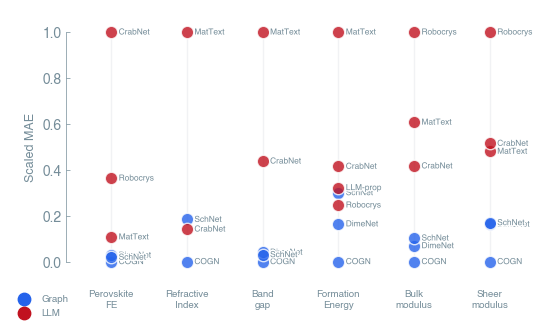

In [143]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.patches import Patch
import matplotlib.patheffects as path_effects

# Define range_frame function
def range_frame(ax, x, y, pad=0.1):
    y_min, y_max = np.array(y).min(), np.array(y).max()
    filtered_x = [val for val in x if val is not None]
    if filtered_x:  
        x_min, x_max = np.min(filtered_x), np.max(filtered_x)  
    else:  
        x_min, x_max = 0, 1  # Default values or handle accordingly

    ax.set_ylim(y_min - pad * (y_max - y_min), y_max + pad * (y_max - y_min))
    ax.set_xlim(x_min - pad * (x_max - x_min), x_max + pad * (x_max - x_min))
    ax.spines["left"].set_position(("outward", 5))  # Reduced from 10 to 5
    ax.spines["bottom"].set_visible(False)  # Hide bottom spine since we're using vertical lines
    ax.spines["left"].set_bounds(y_min, y_max)
    ax.spines["right"].set_visible(False)
    ax.spines["top"].set_visible(False)

# Define the data
data = {
    'COGN': [0.0269, 0.3088, 0.017, 0.1559, 0.0535, 0.0689],
    #'CGCNN': [0.0452, 0.5988, 0.0337, 0.2972, 0.0712, 0.0895],
    'DimeNet': [0.0376, None, 0.0235, 0.1993, 0.0572, 0.0792],
    'SchNet': [0.0342, 0.3277, 0.0218, 0.2352, 0.059, 0.0796],
    'MatText-Best': [0.067748, 0.41169, 0.175, 0.42, 0.086, 0.09922],
    'LLM-prop': [None, None, None, 0.241, None, None],
    'Robocrys': [0.165, None, None, 0.221, 0.107, 0.132],
   # 'RF-SCM': [0.2355, 0.4196, 0.1165, 0.3452, 0.082, 0.104],
    'CrabNet': [0.4065, 0.3234, 0.0862, 0.2655, 0.0758, 0.1014],
    #'Dummy': [0.5660, 0.8088, 1.0059, 1.3272, 0.2897, 0.2931]
}

properties = ['Perovskite\nFE', 'Refractive\nIndex',  'Band\ngap', 'Formation\nEnergy',  'Bulk\nmodulus', 'Sheer\nmodulus']

# Define model types
model_types = {
    'COGN': 'GNN',
    'DimeNet': 'GNN',
    'SchNet': 'GNN',
    'MatText-Best': 'LLM',
    'Robocrys': 'LLM',
    'RF-SCM': 'Other',
    'CrabNet': 'LLM',
    'LLM-prop': 'LLM',
    'Dummy': 'Other'
}

# Convert to DataFrame for easier manipulation
df = pd.DataFrame(data, index=properties).T
df['model_type'] = df.index.map(model_types)

# Function to normalize data per property
def normalize_property(series):
    """Normalize a property series so that min value is 0 and max value is 1"""
    valid = series.dropna()
    if len(valid) <= 1:
        return series  # Can't normalize single value
    min_val = valid.min()
    max_val = valid.max()
    range_val = max_val - min_val
    if range_val == 0:
        return series  # Can't normalize if all values are the same
    return (series - min_val) / range_val

# Create a new DataFrame for normalized values
normalized_df = pd.DataFrame(index=df.index)
normalized_df['model_type'] = df['model_type']

# Create a new DataFrame for normalized values (for visualization)
normalized_size_df = pd.DataFrame(index=df.index)
normalized_size_df['model_type'] = df['model_type']

# Normalize each property
for prop in properties:
    normalized_df[prop] = normalize_property(df[prop])
    # For point sizes, normalize directly from original error values (1 = worst, 0 = best)
    normalized_size_df[prop] = normalize_property(df[prop])


fig, ax = plt.subplots(figsize=(TWO_COL_WIDTH_INCH, TWO_COL_GOLDEN_RATIO_HEIGHT_INCH))

# Create dictionaries to store GNN min and LLM min for each property
gnn_mins = {}
llm_mins = {}

# Collect all y values for range_frame
all_y_values = []

# Draw vertical lines for each property

# Function to scale point size based on normalized error (1 = biggest point)
def scale_point_size(normalized_value, min_size=40, max_size=250):
    """Scale point size based on normalized value - 1 (worst) = largest point"""
    return min_size + normalized_value * (max_size - min_size)

# Plot each model type with different colors
for model_type, color in [('GNN', '#2563eb'), ('LLM', '#c1121f'), ('Other', '#6b7280')]:
    # Get models of this type
    type_models = normalized_df[normalized_df['model_type'] == model_type].index
    
    for model in type_models:
        model_data = normalized_df.loc[model, properties].copy()
        size_data = normalized_size_df.loc[model, properties].copy()  # For point sizing
        
        # Plot each data point for this model
        for i, prop in enumerate(properties):
            if pd.notna(model_data[prop]):
                x_pos = i
                y_pos = model_data[prop]
                all_y_values.append(y_pos)  # Collect y values for range_frame
                
                # Store minimum values for GNN and LLM models
                if model_type == 'GNN' and (prop not in gnn_mins or y_pos < gnn_mins[prop][1]):
                    gnn_mins[prop] = (x_pos, y_pos, model)
                elif model_type == 'LLM' and (prop not in llm_mins or y_pos < llm_mins[prop][1]):
                    llm_mins[prop] = (x_pos, y_pos, model)
                
                # Calculate point size based on normalized error (bigger error = bigger point)
                norm_error = size_data[prop]
                # point_size = scale_point_size(norm_error)
                
                # Plot the point
                ax.scatter(x_pos, y_pos, color=color, s=80, alpha=0.8, 
                           edgecolors='white', linewidth=1, zorder=3)
                text = ax.text(x_pos + 0.1, y_pos, model.replace('-Best', ''),
                               fontsize=6, va='center', ha='left', zorder=4)
                text.set_path_effects([path_effects.withStroke(linewidth=2, foreground='white')])

                # # Add model name label with outline for contrast
                # text = ax.text(x_pos + 0.1, y_pos, model.replace('-Best', ''),
                #                fontsize=6, va='center', ha='left', zorder=4)
                # text.set_path_effects([path_effects.withStroke(linewidth=2, foreground='white')])

# Apply range frame to the plot
x_values = list(range(len(properties)))
range_frame(ax, x_values, all_y_values, pad=0.1)  # Reduced padding for tighter fit
   
# Set the axis labels
#ax.set_xlabel('Material Properties', fontsize=7, fontweight='bold')
ax.set_ylabel('Scaled MAE', fontsize=9, fontweight='bold')

# Set the x-ticks to property names
ax.set_xticks(range(len(properties)))
ax.set_xticklabels(properties, fontsize=7)
ax.tick_params(axis='x', which='both', bottom=False)  # Remove x-axis ticks

for i in range(len(properties)):
    # Get y-axis limits
    y_min, y_max = ax.get_ylim()
    ax.axvline(x=i, color='#d1d5db', alpha=0.3, linestyle='-', ymin=0.1, ymax=0.9, zorder=0)


# Create a custom legend for model types
legend_elements = [
    plt.scatter([], [], c='#2563eb', s=80, label='Graph'),
    plt.scatter([], [], c='#c1121f', s=80, label='LLM'),
]
ax.legend(handles=legend_elements, loc='lower left', 
          bbox_to_anchor=(-0.15, -0.15),
          fontsize=7)



# Adjust layout and save
plt.tight_layout()
output_dir = "fig3"
os.makedirs(output_dir, exist_ok=True)
plot_filename = os.path.join(output_dir, "llm_gnn_wall_2.pdf")
plt.savefig(plot_filename,format='pdf', bbox_inches='tight')
plt.show()

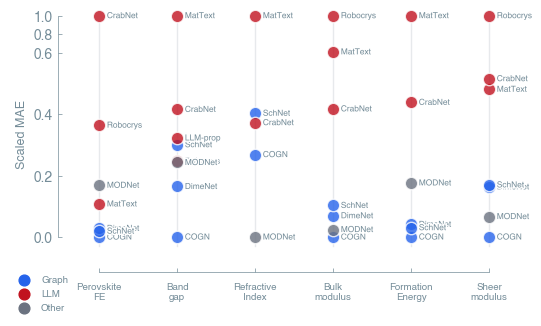

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.patches import Patch
import matplotlib.patheffects as path_effects
import os # For saving the plot

# Imports for custom scale
import matplotlib.scale as mscale
import matplotlib.transforms as mtransforms
import matplotlib.ticker as mticker

# --- Custom Scale Definition ---
class SquishScale(mscale.ScaleBase):
    name = 'squish'

    def __init__(self, axis, **kwargs):
        super().__init__(axis)
        self.cutoff = kwargs.pop("cutoff", 0.6)
        self.compression = kwargs.pop("compression", 0.3)
        if self.compression <= 0 or self.compression > 1:
            raise ValueError("Compression factor must be between 0 (exclusive) and 1 (inclusive)")

    def get_transform(self):
        return self.SquishTransform(self.cutoff, self.compression)

    def set_default_locators_and_formatters(self, axis):
        axis.set_major_locator(mticker.AutoLocator())
        axis.set_major_formatter(mticker.ScalarFormatter())
        axis.set_minor_locator(mticker.NullLocator())

    class SquishTransform(mtransforms.Transform):
        input_dims = 1
        output_dims = 1
        is_separable = True
        has_inverse = True

        def __init__(self, cutoff, compression):
            super().__init__()
            self.cutoff = cutoff
            self.compression = compression

        def transform_non_affine(self, a):
            res = np.copy(a).astype(float)
            mask = res > self.cutoff
            res[mask] = self.cutoff + (res[mask] - self.cutoff) * self.compression
            return res

        def inverted(self):
            return SquishScale.InvertedSquishTransform(self.cutoff, self.compression)

    class InvertedSquishTransform(mtransforms.Transform):
        input_dims = 1
        output_dims = 1
        is_separable = True
        has_inverse = True

        def __init__(self, cutoff, compression):
            super().__init__()
            self.cutoff = cutoff
            self.compression = compression

        def transform_non_affine(self, a):
            res = np.copy(a).astype(float)
            mask = res > self.cutoff
            res[mask] = self.cutoff + (res[mask] - self.cutoff) / self.compression
            return res

mscale.register_scale(SquishScale)
# --- End Custom Scale Definition ---

# Define range_frame function
def range_frame(ax, x, y_data_range, pad=0.1): # y_data_range is conceptual [0,1]
    # For ylim, consider the requested data range (typically 0 to 1 for normalized MAE)
    effective_y_min = y_data_range[0]
    effective_y_max = y_data_range[1]

    ax.set_ylim(effective_y_min - pad * (effective_y_max - effective_y_min),
                effective_y_max + pad * (effective_y_max - effective_y_min))

    filtered_x = [val for val in x if val is not None]
    if filtered_x:
        x_min, x_max = np.min(filtered_x), np.max(filtered_x)
    else:
        x_min, x_max = 0, 1

    ax.set_xlim(x_min - pad * (x_max - x_min), x_max + pad * (x_max - x_min))

    # Using user's preference for spines
    ax.spines["left"].set_position(("outward", 10))
    ax.spines["bottom"].set_position(("outward", 10)) # Show bottom spine
    ax.spines["left"].set_bounds(effective_y_min, effective_y_max)
    if filtered_x: # Only set bounds if x_min, x_max are valid
        ax.spines["bottom"].set_bounds(x_min, x_max)
    else:
        ax.spines["bottom"].set_visible(False) # Hide if no x data

    ax.spines["right"].set_visible(False)
    ax.spines["top"].set_visible(False)

# Define the data
data = {
    'COGN': [0.0269, 0.3088, 0.017, 0.1559, 0.0535, 0.0689],
    'DimeNet': [0.0376, None, 0.0235, 0.1993, 0.0572, 0.0792],
    'SchNet': [0.0342, 0.3277, 0.0218, 0.2352, 0.059, 0.0796],
    'MatText-Best': [0.067748, 0.41169, 0.175, 0.42, 0.086, 0.09922],
    'LLM-prop': [None, None, None, 0.241, None, None],
    'Robocrys': [0.165, None, None, 0.221, 0.107, 0.132],
    #'RF-SCM': [0.2355, 0.4196, 0.1165, 0.3452, 0.082, 0.104],
    'CrabNet': [0.4065, 0.3234, 0.0862, 0.2655, 0.0758, 0.1014],
    #'Dummy': [0.5660,0.8088, 1.0059,1.3272,0.2897,0.2931]
    "MODNet": [0.0908, 0.2711, 0.0448, 0.2199, 0.0548, 0.0731],
}

# Initial properties list (will be reordered)
initial_properties = ['Perovskite\nFE', 'Refractive\nIndex', 'Formation\nEnergy', 'Band\ngap', 'Bulk\nmodulus', 'Sheer\nmodulus']

# Define model types
model_types = {
    'COGN': 'GNN', 'DimeNet': 'GNN', 'SchNet': 'GNN',
    'MatText-Best': 'LLM', 'Robocrys': 'LLM', 
    'CrabNet': 'LLM', 'LLM-prop': 'LLM', 
    'RF-SCM': 'Other', 'MODNet': 'Other', 'Dummy': 'Other'
}

# Convert to DataFrame for easier manipulation
# Corrected: use 'data' instead of 'raw_data'
df = pd.DataFrame(data, index=initial_properties).T
df['model_type'] = df.index.map(model_types)

# Function to normalize data per property
def normalize_property(series):
    valid = series.dropna()
    if len(valid) <= 1: return series
    min_val = valid.min()
    max_val = valid.max()
    range_val = max_val - min_val
    if range_val == 0: return series
    return (series - min_val) / range_val

# Create a new DataFrame for normalized values
normalized_df = pd.DataFrame(index=df.index)
normalized_df['model_type'] = df['model_type']

# Normalize each property
for prop in initial_properties:
    normalized_df[prop] = normalize_property(df[prop])

# --- Determine property order based on LLM minimum scaled MAE ---
llm_min_maes = {}
llm_models_df = normalized_df[normalized_df['model_type'] == 'LLM']

for prop in initial_properties:
    if not llm_models_df.empty and prop in llm_models_df.columns:
        min_mae_for_prop = llm_models_df[prop].dropna().min()
        if pd.notna(min_mae_for_prop):
            llm_min_maes[prop] = min_mae_for_prop
        else:
            llm_min_maes[prop] = float('inf') # If no LLM data for a prop, put it last
    else:
        llm_min_maes[prop] = float('inf')

# Sort properties by the minimum LLM MAE
sorted_properties_tuples = sorted(llm_min_maes.items(), key=lambda item: item[1])
properties = [item[0] for item in sorted_properties_tuples] # This is the new ordered list



fig, ax = plt.subplots(figsize=(TWO_COL_WIDTH_INCH, TWO_COL_GOLDEN_RATIO_HEIGHT_INCH))

# Apply the custom Y scale
ax.set_yscale('squish', cutoff=0.6, compression=0.3)
ax.set_yticks([0.0, 0.2, 0.4, 0.6, 0.8, 1.0]) # Explicit ticks for clarity

all_y_values_for_range_frame = [] # Collect all y_pos for range_frame min/max

# Plot each model type with different colors
for model_type, color in [('GNN', '#2563eb'), ('LLM', '#c1121f'), ('Other', '#6b7280')]:
    type_models = normalized_df[normalized_df['model_type'] == model_type].index
    
    for model in type_models:
        # Use the new 'properties' order for accessing data
        model_data = normalized_df.loc[model, properties].copy()
        
        for i, prop in enumerate(properties): # Iterate using the new sorted 'properties'
            if pd.notna(model_data[prop]):
                x_pos = i
                y_pos = model_data[prop]
                all_y_values_for_range_frame.append(y_pos)
                
                ax.scatter(x_pos, y_pos, color=color, s=80, alpha=0.8,
                           edgecolors='white', linewidth=1, zorder=3)
                
                # Add model name label with outline for contrast and GRAY color
                text_label = model.replace('-Best', '')

                text = ax.text(x_pos + 0.1, y_pos, model.replace('-Best', ''),
                               fontsize=6, va='center', ha='left', zorder=4)
                text.set_path_effects([path_effects.withStroke(linewidth=2, foreground='white')])
                # text = ax.text(x_pos + 0.1, y_pos, text_label,
                #                fontsize=6, va='center', ha='left', zorder=4, color='dimgray') # Changed to dimgray
                # text.set_path_effects([path_effects.withStroke(linewidth=1.5, foreground='white')])

# Apply range frame to the plot
x_values = list(range(len(properties)))
# Pass the conceptual [0,1] range for y as the data is normalized to this.
range_frame(ax, x_values, [0.0, 1.0], pad=0.07) # Reduced padding for y, increased for x for labels

# Set the axis labels
#ax.set_xlabel('Material Properties', fontsize=7, fontweight='bold')
ax.set_ylabel('Scaled MAE', fontsize=9, fontweight='bold') # Changed "lowest" to "worst"

# Set the x-ticks to property names (using the new sorted 'properties' list)
ax.set_xticks(range(len(properties)))
ax.set_xticklabels([p.replace(' ', '\n') for p in properties], fontsize=7) # Use the sorted properties
ax.tick_params(axis='x', which='major', pad=7) # Add padding for x-tick labels

# Add vertical lines for property separation
for i in range(len(properties)):
    ax.axvline(x=i, color='#d1d5db', alpha=0.5, linestyle='-', ymin=0.05, ymax=0.95, zorder=0)

# Custom legend (kept commented as per your script, but this version is from previous solution)
legend_elements = [
    plt.scatter([], [], c='#2563eb', s=60, label='Graph'),
    plt.scatter([], [], c='#c1121f', s=60, label='LLM'), # Matched color with plot
    plt.scatter([], [], c='#6b7280', s=60, label='Other'), # Gray for other models
]
ax.legend(handles=legend_elements, loc='lower left',
          bbox_to_anchor=(-0.15, -0.25), # Adjust anchor as needed
          fontsize=7, frameon=False)

# Adjust layout and save
plt.tight_layout() # Add bottom margin for legend
output_dir = "fig3" # Define an output directory
os.makedirs(output_dir, exist_ok=True)
plot_filename = os.path.join(output_dir, "llm_gnn_wall_yaxis_scaled_ordered_with_modnet.pdf")
plt.savefig(plot_filename, format='pdf', bbox_inches='tight')
plt.savefig(plot_filename.replace('.pdf', '.png'), format='png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
data = {
    'COGN': [0.0269, 0.3088,  0.1559, 0.0535,0.017, 0.0689],
    #'CGCNN': [0.0452, 0.5988, 0.0337, 0.2972, 0.0712, 0.0895],
    'DimeNet': [0.0376, None,  0.1993, 0.0572, 0.0235,0.0792],
    'SchNet': [0.0342, 0.3277,  0.2352, 0.059, 0.0218, 0.0796],
    'MatText-Best': [0.067748, 0.41169, 0.42, 0.086,  0.175, 0.09922],
    #'LLM-prop': [None, None, None, 0.241, None, None],
    'Robocrys': [0.165, None, 0.221, 0.107, None,  0.132],
    'RF-SCM': [0.2355, 0.4196,  0.3452, 0.082, 0.1165, 0.104],
    'CrabNet': [0.4065, 0.3234, 0.2655, 0.0758, 0.0862,  0.1014],
    'Dummy': [0.5660,0.8088,1.3272,0.2897, 1.0059, 0.2931]

}

# Create a DataFrame
index = ['perov-FM', 'dielectric const', 'formation E', 'band gap', 'bulk modulus', 'sheer modulus']